In [36]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)
print("done")

done


In [37]:
import os
print(os.listdir("../data/"))

['Cities.csv', 'Continents.csv', 'Countries.csv', 'Item.csv', 'Regions.csv', 'Transaction.csv', 'Types.csv', 'Updated_Item.xlsx - Sheet1.csv', 'User.csv', 'VisitingMode.csv']


In [38]:
#Load Datasets
path = '../data/'

trans        = pd.read_csv(path + 'Transaction.csv')
users        = pd.read_csv(path + 'User.csv')
cities       = pd.read_csv(path + 'Cities.csv')
countries    = pd.read_csv(path + 'Countries.csv')
regions      = pd.read_csv(path + 'Regions.csv')
continents   = pd.read_csv(path + 'Continents.csv')
items        = pd.read_csv(path + 'Item.csv')
updated_item = pd.read_csv(path + 'Updated_Item.xlsx - Sheet1.csv')
types        = pd.read_csv(path + 'Types.csv')
modes        = pd.read_csv(path + 'VisitingMode.csv')

print('trans        ->', trans.shape)
print('users        ->', users.shape)
print('cities       ->', cities.shape)
print('countries    ->', countries.shape)
print('regions      ->', regions.shape)
print('continents   ->', continents.shape)
print('items        ->', items.shape)
print('updated_item ->', updated_item.shape)
print('types        ->', types.shape)
print('modes        ->', modes.shape)

trans        -> (52930, 7)
users        -> (33530, 5)
cities       -> (9143, 3)
countries    -> (165, 3)
regions      -> (22, 3)
continents   -> (6, 2)
items        -> (30, 5)
updated_item -> (1698, 5)
types        -> (17, 2)
modes        -> (6, 2)


In [39]:
# check columns of each before merging
print('trans cols       :', trans.columns.tolist())
print('users cols       :', users.columns.tolist())
print('cities cols      :', cities.columns.tolist())
print('countries cols   :', countries.columns.tolist())
print('regions cols     :', regions.columns.tolist())
print('continents cols  :', continents.columns.tolist())
print('items cols       :', items.columns.tolist())
print('updated_item cols:', updated_item.columns.tolist())
print('types cols       :', types.columns.tolist())
print('modes cols       :', modes.columns.tolist())

trans cols       : ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']
users cols       : ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']
cities cols      : ['CityId', 'CityName', 'CountryId']
countries cols   : ['CountryId', 'Country', 'RegionId']
regions cols     : ['Region', 'RegionId', 'ContinentId']
continents cols  : ['ContinentId', 'Continent']
items cols       : ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']
updated_item cols: ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']
types cols       : ['AttractionTypeId', 'AttractionType']
modes cols       : ['VisitModeId', 'VisitMode']


In [40]:
#Marge datasets
cities_clean    = cities[['CityId', 'CityName']]
countries_clean = countries[['CountryId', 'Country']]
regions_clean   = regions[['RegionId', 'Region']]
users = users.merge(cities_clean,    on='CityId',      how='left') \
             .merge(countries_clean, on='CountryId',   how='left') \
             .merge(regions_clean,   on='RegionId',    how='left') \
             .merge(continents,      on='ContinentId', how='left')

items_full = items.merge(types, on='AttractionTypeId', how='left')

df = trans.merge(users,                                                      on='UserId',      how='left') \
          .merge(items_full[['AttractionId','AttractionTypeId',
                              'Attraction','AttractionType']], on='AttractionId', how='left')

print('final shape:', df.shape)
df.head(5)

final shape: (52930, 18)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,CityName,Country,Region,Continent,AttractionTypeId,Attraction,AttractionType
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,Guildford,United Kingdom,Western Europe,Europe,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas
1,8,7567,2022,10,4,640,5,2,8,48,464.0,Ontario,Canada,Northern America,America,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas
2,9,79069,2022,10,3,640,5,2,9,54,774.0,Brazil,Brazil,South America,America,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas
3,10,31019,2022,10,3,640,3,5,17,135,583.0,Zurich,Switzerland,Central Europe,Europe,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,Manchester,United Kingdom,Western Europe,Europe,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas


In [41]:
#Check null values and data types
print('columns:\n', df.columns.tolist())
print('\nnull values:\n', df.isnull().sum())
print('\ndtypes:\n', df.dtypes)

columns:
 ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'CityName', 'Country', 'Region', 'Continent', 'AttractionTypeId', 'Attraction', 'AttractionType']

null values:
 TransactionId       0
UserId              0
VisitYear           0
VisitMonth          0
VisitMode           0
AttractionId        0
Rating              0
ContinentId         0
RegionId            0
CountryId           0
CityId              8
CityName            8
Country             0
Region              0
Continent           0
AttractionTypeId    0
Attraction          0
AttractionType      0
dtype: int64

dtypes:
 TransactionId         int64
UserId                int64
VisitYear             int64
VisitMonth            int64
VisitMode             int64
AttractionId          int64
Rating                int64
ContinentId           int64
RegionId              int64
CountryId             int64
CityId              float64
CityNa

# Data Cleaning

In [42]:
# drop rows where rating or visit mode is missing
df.dropna(subset=['Rating', 'VisitMode'], inplace=True)

# keep rating between 1 and 5 only
df = df[df['Rating'].between(1, 5)]

# strip whitespace from all string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df.reset_index(drop=True, inplace=True)

print('clean shape:', df.shape)
print('\nVisitMode counts:\n', df['VisitMode'].value_counts())
print('\nRating stats:\n', df['Rating'].describe())

clean shape: (52930, 18)

VisitMode counts:
 VisitMode
2    21620
3    15217
4    10945
5     4525
1      623
Name: count, dtype: int64

Rating stats:
 count    52930.000000
mean         4.157699
std          0.970543
min          1.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64


# Rating Distribution and Visit Mode Counts

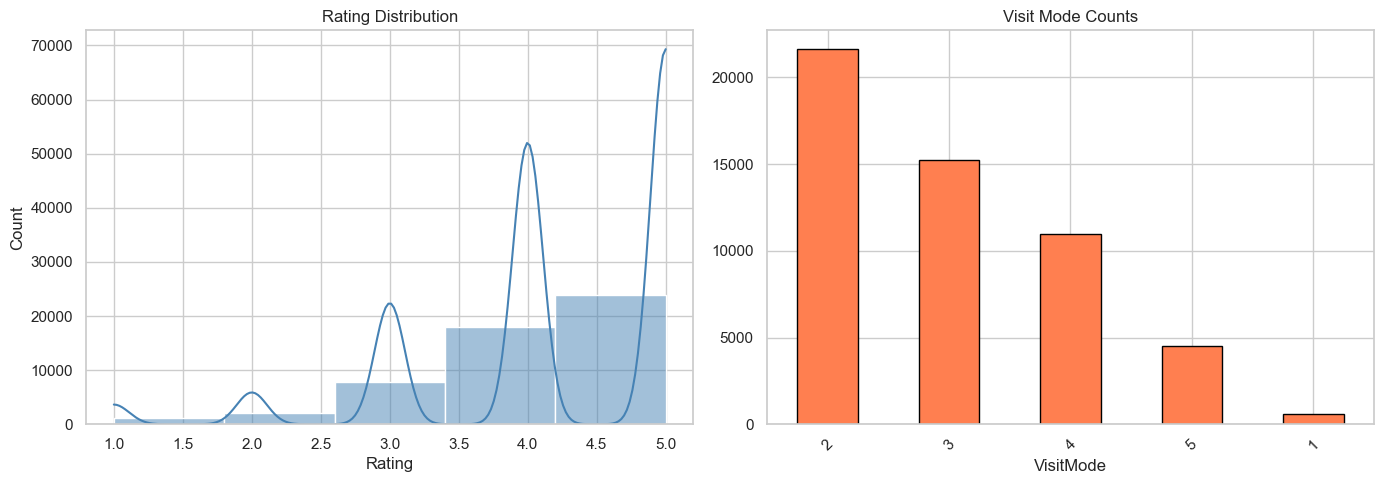

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Rating'], bins=5, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')

df['VisitMode'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Visit Mode Counts')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Top Countries and Avg Rating by Continent

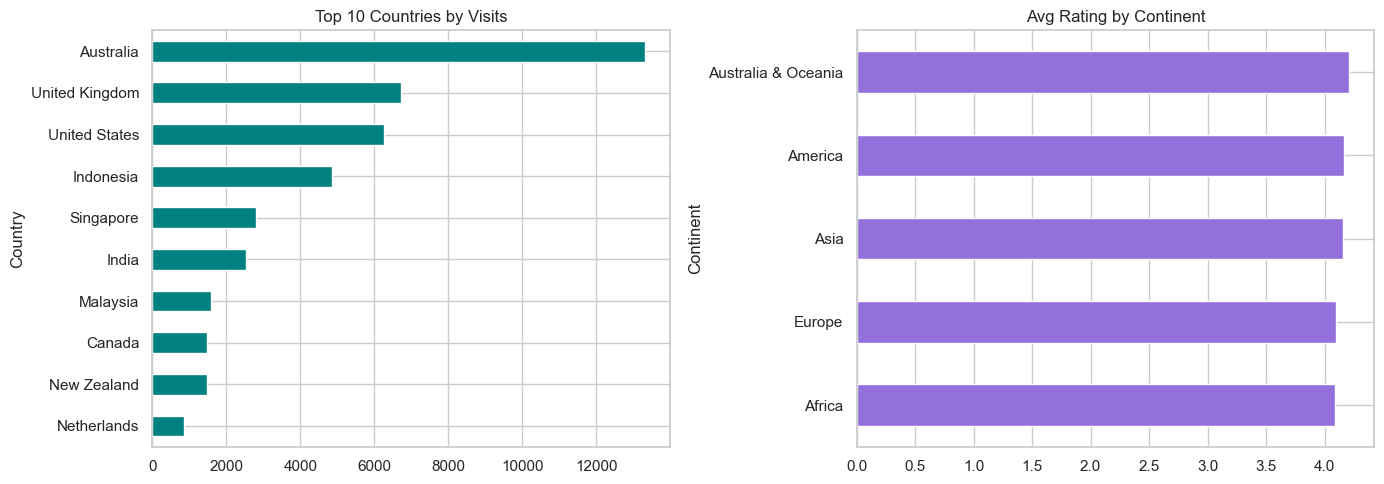

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Country'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 10 Countries by Visits')
axes[0].invert_yaxis()

df.groupby('Continent')['Rating'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='mediumpurple'
)
axes[1].set_title('Avg Rating by Continent')

plt.tight_layout()
plt.show()

# Top Attraction Types and Monthly Travel Trend

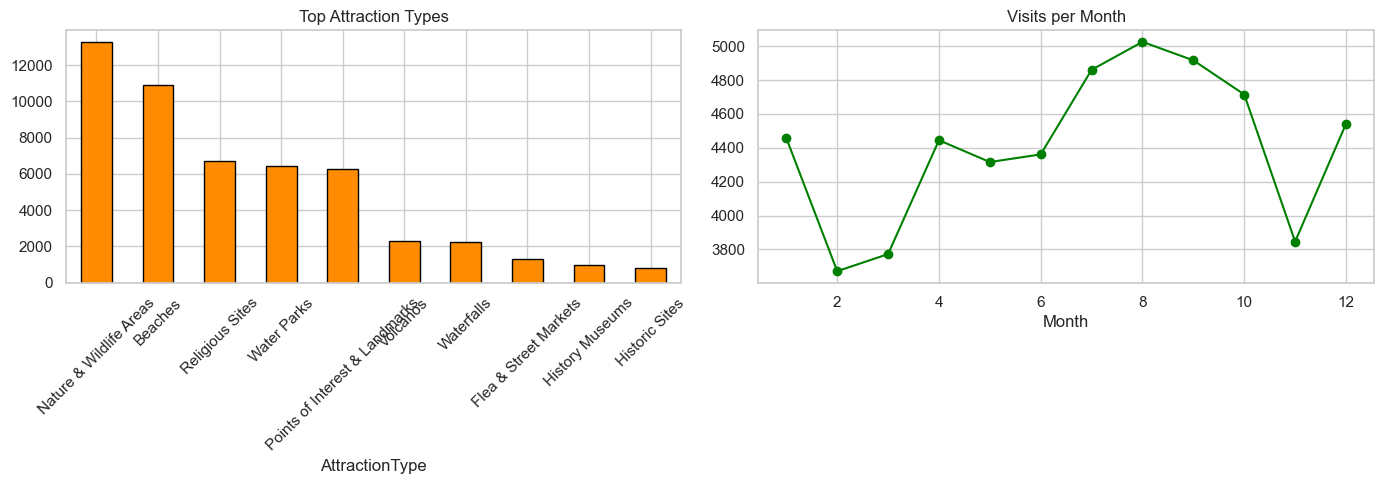

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['AttractionType'].value_counts().head(10).plot(
    kind='bar', ax=axes[0], color='darkorange', edgecolor='black'
)
axes[0].set_title('Top Attraction Types')
axes[0].tick_params(axis='x', rotation=45)

df['VisitMonth'].value_counts().sort_index().plot(
    kind='line', ax=axes[1], marker='o', color='green'
)
axes[1].set_title('Visits per Month')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

# Rating by Visit Mode

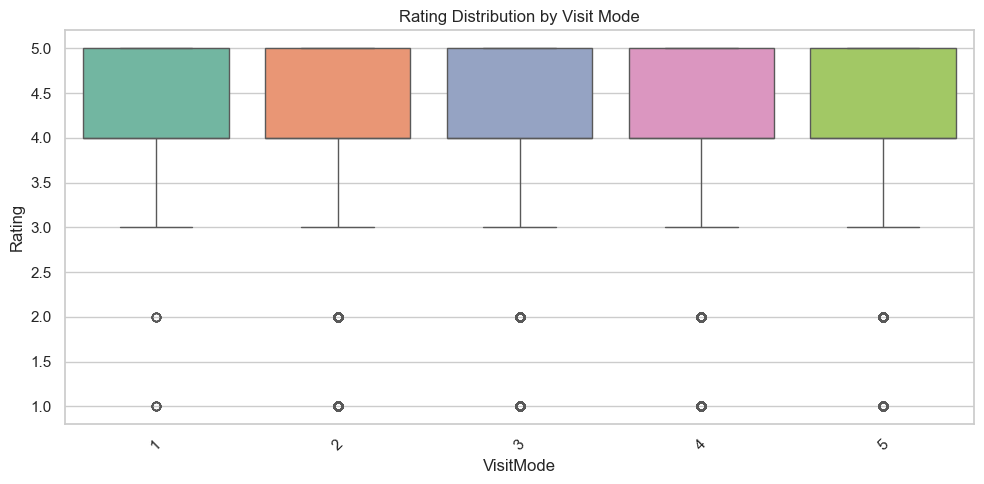

In [46]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='VisitMode', y='Rating', data=df, palette='Set2')
plt.title('Rating Distribution by Visit Mode')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Yearly Visit Trend

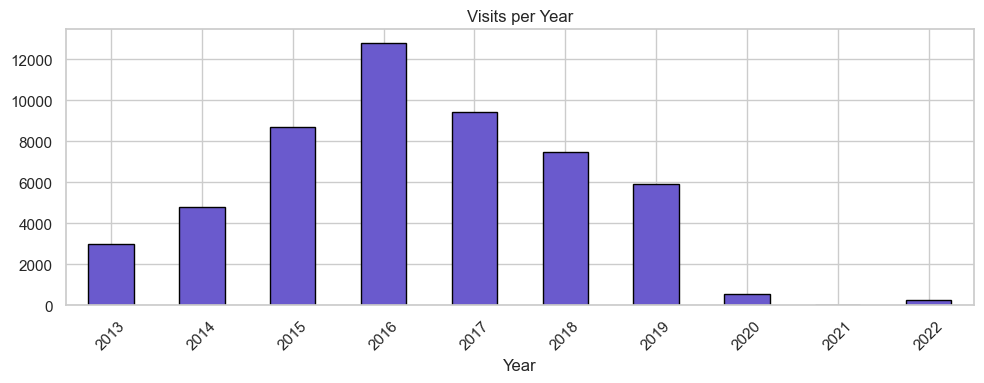

In [47]:
plt.figure(figsize=(10, 4))
df['VisitYear'].value_counts().sort_index().plot(kind='bar', color='slateblue', edgecolor='black')
plt.title('Visits per Year')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top 10 Most Visited Attractions

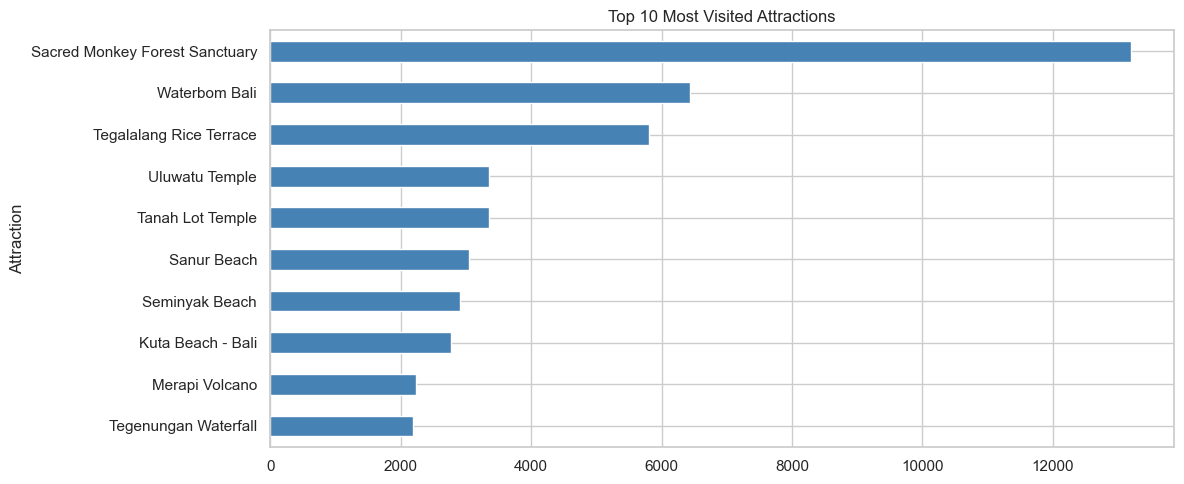

In [48]:
plt.figure(figsize=(12, 5))
df['Attraction'].value_counts().head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Visited Attractions')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save Cleaned Data

In [49]:
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/processed_data.csv', index=False)
print('saved ✅  shape:', df.shape)

saved ✅  shape: (52930, 18)
